In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [ ]:
wd = 0.642570281124498
wm = 0.642570281124498
tlist = np.linspace(0, 100, 200)
N = 8
dlist = np.linspace(0, 1, 11)

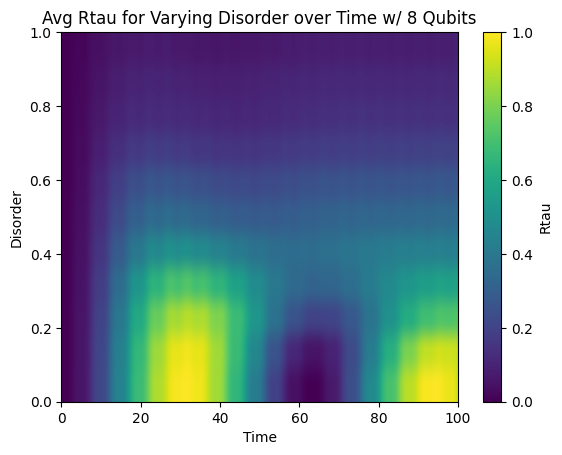

In [3]:
densityAvgRtau_scar = []
for d in dlist:
    scar_dR = []
    for _ in range(200):
        H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, disorder=True, detuning=d, random_seed=True)
        args = {"A": 0.1, "omega": wd}
        H = qt.QobjEvo([H0, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
        Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])
        scar_dR.append(Rtau)
        
    scar_dR = np.array(scar_dR)
    densityAvgRtau_scar.append(np.mean(scar_dR, axis=0))

plt.imshow(densityAvgRtau_scar,
           extent=[tlist.min(), tlist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Rtau")
plt.title(f"Avg Rtau for Varying Disorder over Time w/ {N} Qubits")
plt.ylabel("Disorder")
plt.xlabel("Time")
plt.show()

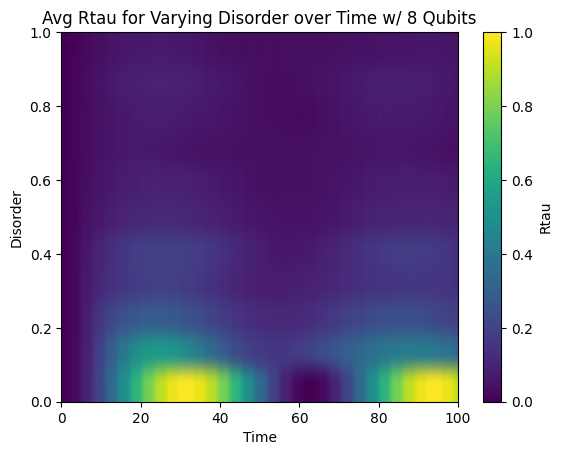

In [5]:
densityAvgRtau_qubit = []
for d in dlist:
    qubit_dR = []
    for _ in range(25):
        qH0, qH1, wm = get_qubit_ham(N, wm=1.0, disorder=True, detuning=d, random_seed=True)
        qeigvals, qeigstates = qH0.eigenstates()
        qband = qeigvals[-1] - qeigvals[0]

        qargs = {"A": 0.1, "omega": wm}
        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigstates[0], tlist, e_ops=[qH0])
        qRtau = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qband
        qubit_dR.append(qRtau)
        
    qubit_dR = np.array(qubit_dR)
    densityAvgRtau_qubit.append(np.mean(qubit_dR, axis=0))

plt.imshow(densityAvgRtau_qubit,
           extent=[tlist.min(), tlist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Rtau")
plt.title(f"Avg Rtau for Varying Disorder over Time w/ {N} Qubits")
plt.ylabel("Disorder")
plt.xlabel("Time")
plt.show()